#  Entraînement du Modèle ML
## Projet : Prédiction du Churn Client - Télécoms

### Objectif
Entraîner et évaluer des modèles de Machine Learning pour prédire le churn.

**Étapes :**
1. Charger les données préparées
2. Séparer en train/test
3. Entraîner une Régression Logistique (baseline)
4. Entraîner XGBoost
5. Comparer les performances
6. Sauvegarder le meilleur modèle

### Métriques cibles
| Métrique | Objectif | Pourquoi |
|----------|----------|----------|
| **Recall** | > 80% | Détecter un maximum de churners |
| **Precision** | > 70% | Limiter les fausses alertes |
| **F1-Score** | > 0.75 | Équilibre recall/precision |

In [2]:
# =============================================================
# IMPORTS DES BIBLIOTHÈQUES
# =============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, f1_score)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import pickle

# Affichage
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

print(" Bibliothèques importées avec succès !")

 Bibliothèques importées avec succès !


##  1. Chargement des Données Préparées

On charge les données déjà nettoyées et enrichies
depuis le dossier `data/processed/`.

In [3]:
# =============================================================
# CHARGEMENT DES DONNÉES PRÉPARÉES
# =============================================================

# Chargement des données préparées
df = pd.read_csv('../data/processed/telco_churn_processed.csv')

# Vérification
print(f" Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"\n Distribution du Churn :")
print(df['Churn'].value_counts())
print(f"\n Pourcentage :")
print(df['Churn'].value_counts(normalize=True).round(3) * 100)

 Dataset chargé : 7043 lignes, 33 colonnes

 Distribution du Churn :
Churn
0    5174
1    1869
Name: count, dtype: int64

 Pourcentage :
Churn
0    73.5
1    26.5
Name: proportion, dtype: float64


##  2. Séparation Train / Test

On sépare les données en deux parties :
- **80% Train** : le modèle apprend sur ces données
- **20% Test** : on évalue le modèle sur des données qu'il n'a jamais vues

 Cette séparation est fondamentale.
Si on évalue le modèle sur les mêmes données qu'il a apprises,
il aura l'air très performant mais sera inutile en production.
C'est comme donner les réponses à un étudiant avant l'examen.

In [4]:
# =============================================================
# SÉPARATION TRAIN / TEST
# =============================================================

# Séparer les features (X) de la cible (y)
# X = toutes les colonnes sauf Churn
# y = la colonne Churn uniquement
X = df.drop('Churn', axis=1)
y = df['Churn']

print(f" Features (X) : {X.shape[1]} colonnes")
print(f" Cible (y) : {y.shape[0]} valeurs")

# Séparation 80% train / 20% test
# random_state=42 → pour avoir les mêmes résultats à chaque fois
# stratify=y → garde le même ratio 73.5/26.5 dans train et test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print(f"\n Séparation effectuée :")
print(f"  Train : {X_train.shape[0]} clients ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"  Test  : {X_test.shape[0]} clients ({X_test.shape[0]/len(df)*100:.0f}%)")

print(f"\n Distribution du Churn dans Train :")
print(y_train.value_counts(normalize=True).round(3) * 100)

 Features (X) : 32 colonnes
 Cible (y) : 7043 valeurs

 Séparation effectuée :
  Train : 5634 clients (80%)
  Test  : 1409 clients (20%)

 Distribution du Churn dans Train :
Churn
0    73.5
1    26.5
Name: proportion, dtype: float64


##  3. Équilibrage avec SMOTE

Le dataset est déséquilibré (73.5% vs 26.5%).
On applique SMOTE uniquement sur les données d'entraînement.

Important : on n'applique JAMAIS SMOTE sur les données de test.
Les données de test doivent rester réelles pour évaluer
les vraies performances du modèle en production.

In [5]:
# =============================================================
# ÉQUILIBRAGE AVEC SMOTE
# =============================================================

# Appliquer SMOTE uniquement sur les données d'entraînement
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(" SMOTE appliqué avec succès !")
print(f"\n Avant SMOTE :")
print(f"  Non-Churn : {y_train.value_counts()[0]} clients")
print(f"  Churn     : {y_train.value_counts()[1]} clients")

print(f"\n Après SMOTE :")
print(f"  Non-Churn : {y_train_bal.value_counts()[0]} clients")
print(f"  Churn     : {y_train_bal.value_counts()[1]} clients")

print(f"\n Taille du dataset d'entraînement :")
print(f"  Avant : {X_train.shape[0]} clients")
print(f"  Après : {X_train_bal.shape[0]} clients")

 SMOTE appliqué avec succès !

 Avant SMOTE :
  Non-Churn : 4139 clients
  Churn     : 1495 clients

 Après SMOTE :
  Non-Churn : 4139 clients
  Churn     : 4139 clients

 Taille du dataset d'entraînement :
  Avant : 5634 clients
  Après : 8278 clients


On voit maintenant que le dataset est parfaitement équilibré 50/50 dans l'échantillon test.

##  4. Modèle Baseline : Régression Logistique

On commence par un modèle simple comme point de référence.
Si XGBoost ne fait pas mieux que ça, il y a donc un problème. 

Nous savons que la Régression Logistique nécessite une normalisation des données
(StandardScaler) car elle est sensible à l'échelle des variables.

In [6]:
# =============================================================
# MODÈLE BASELINE : RÉGRESSION LOGISTIQUE
# =============================================================

# 1. Normalisation des données
# La régression logistique est sensible à l'échelle des variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

# 2. Entraînement
print(" Entraînement de la Régression Logistique...")
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train_bal)

# 3. Prédictions
y_pred_lr = lr_model.predict(X_test_scaled)

# 4. Évaluation
print(" Entraînement terminé !")
print("\n RÉSULTATS - Régression Logistique :")
print("=" * 50)
print(classification_report(y_test, y_pred_lr, 
                            target_names=['Non-Churn', 'Churn']))

# 5. Score AUC
auc_lr = roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:, 1])
print(f" AUC Score : {auc_lr:.3f}")

 Entraînement de la Régression Logistique...
 Entraînement terminé !

 RÉSULTATS - Régression Logistique :
              precision    recall  f1-score   support

   Non-Churn       0.85      0.86      0.85      1035
       Churn       0.59      0.58      0.58       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409

 AUC Score : 0.829


- Précision : 59% < (>70% [objectif]) donc sur 100 alertes churn, 59 sont vraies.
- Recall : 63% < (>80% [objectif]) donc on détecte 63% des vrais churners;
- F1-Score : 0.61 donc en dessous de notre objectif de 0.75.

La Régression Logistique n'est donc pas assez performante.
on va entraîner XGBoost et voir si on peut faire mieux.


##  5. Modèle XGBoost

XGBoost est un algorithme plus puissant que la Régression Logistique.
Il crée des arbres de décision un par un, chaque arbre corrigeant
les erreurs du précédent.

Avantages par rapport à la Régression Logistique :
- Capture des relations non-linéaires entre les variables
- Moins sensible à l'échelle des données
- Généralement plus précis sur les données tabulaires (qui est notre cas ici)

In [7]:
# =============================================================
# MODÈLE XGBOOST
# =============================================================

# 1. Entraînement
print(" Entraînement de XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=200,      # Nombre d'arbres
    max_depth=5,           # Profondeur maximale de chaque arbre
    learning_rate=0.1,     # Vitesse d'apprentissage
    random_state=42,       # Reproductibilité
    eval_metric='logloss'  # Métrique d'évaluation
)
xgb_model.fit(X_train_bal, y_train_bal)

# 2. Prédictions
y_pred_xgb = xgb_model.predict(X_test)

# 3. Évaluation
print(" Entraînement terminé !")
print("\n RÉSULTATS - XGBoost :")
print("=" * 50)
print(classification_report(y_test, y_pred_xgb,
                            target_names=['Non-Churn', 'Churn']))

# 4. Score AUC
auc_xgb = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])
print(f" AUC Score : {auc_xgb:.3f}")

 Entraînement de XGBoost...


 Entraînement terminé !

 RÉSULTATS - XGBoost :
              precision    recall  f1-score   support

   Non-Churn       0.85      0.84      0.85      1035
       Churn       0.57      0.60      0.59       374

    accuracy                           0.78      1409
   macro avg       0.71      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409

 AUC Score : 0.820


On voit a notre grande surprise que le modèle XGBoost fait moins bien que la Régression Logistique. Le problème vient probablement des hyperparamètres c'est a dire les réglages du modèle ne sont pas optimaux.

On va essayé d'optimiser les hyperparamètres de XGBoost pour trouver les meilleurs réglages.

##  6. Optimisation des Hyperparamètres XGBoost

Les hyperparamètres sont les réglages du modèle.
On va tester plusieurs combinaisons pour trouver les meilleurs.

On utilise GridSearchCV qui teste toutes les combinaisons possibles
et garde la meilleure.

In [8]:
# =============================================================
# OPTIMISATION DES HYPERPARAMÈTRES XGBOOST
# =============================================================

from sklearn.model_selection import GridSearchCV

# Paramètres à tester
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

print(" Recherche des meilleurs hyperparamètres...")

# GridSearchCV teste toutes les combinaisons
# cv=5 → validation croisée sur 5 groupes
# scoring='f1' → on optimise le F1-Score
grid_search = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,  # Utilise tous les processeurs disponibles
    verbose=1
)

grid_search.fit(X_train_bal, y_train_bal)

print(f"\n Meilleurs hyperparamètres trouvés :")
print(grid_search.best_params_)
print(f"\n Meilleur F1-Score en validation : {grid_search.best_score_:.3f}")

 Recherche des meilleurs hyperparamètres...
Fitting 5 folds for each of 54 candidates, totalling 270 fits



 Meilleurs hyperparamètres trouvés :
{'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}

 Meilleur F1-Score en validation : 0.827


Les meilleurs hyperparamètres trouvés :

- learning_rate : 0.1
- max_depth : 7 (plus profond que les 5 qu'on avait !)
- n_estimators : 200
- subsample : 1.0

F1-Score en validation : 0.825, ce qui est au dessus de notre objectif de 0.75.

##  7. Évaluation du Meilleur Modèle XGBoost

On évalue le meilleur modèle trouvé par GridSearchCV
sur les données de test.

In [9]:
# =============================================================
# ÉVALUATION DU MEILLEUR MODÈLE XGBOOST
# =============================================================

# Meilleur modèle trouvé par GridSearchCV
best_xgb = grid_search.best_estimator_

# Prédictions
y_pred_best = best_xgb.predict(X_test)

# Évaluation
print(" RÉSULTATS - Meilleur XGBoost :")
print("=" * 50)
print(classification_report(y_test, y_pred_best,
                            target_names=['Non-Churn', 'Churn']))

# AUC Score
auc_best = roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:, 1])
print(f" AUC Score : {auc_best:.3f}")

# Comparaison finale
print("\n COMPARAISON FINALE :")
print("=" * 50)
print(f"{'Métrique':<20} {'Baseline LR':<15} {'XGBoost Optimisé':<15} {'Objectif'}")
print("-" * 65)

y_pred_lr_churn = lr_model.predict(X_test_scaled)
report_lr = classification_report(y_test, y_pred_lr_churn, output_dict=True)
report_xgb = classification_report(y_test, y_pred_best, output_dict=True)

print(f"{'Recall Churn':<20} {report_lr['1']['recall']:.2%}{'':>8} {report_xgb['1']['recall']:.2%}{'':>8} >80%")
print(f"{'Precision Churn':<20} {report_lr['1']['precision']:.2%}{'':>8} {report_xgb['1']['precision']:.2%}{'':>8} >70%")
print(f"{'F1-Score Churn':<20} {report_lr['1']['f1-score']:.3f}{'':>9} {report_xgb['1']['f1-score']:.3f}{'':>9} >0.75")
print(f"{'AUC':<20} {auc_lr:.3f}{'':>9} {auc_best:.3f}{'':>9} >0.80")

 RÉSULTATS - Meilleur XGBoost :
              precision    recall  f1-score   support

   Non-Churn       0.87      0.83      0.85      1035
       Churn       0.58      0.64      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409

 AUC Score : 0.835

 COMPARAISON FINALE :
Métrique             Baseline LR     XGBoost Optimisé Objectif
-----------------------------------------------------------------
Recall Churn         57.75%         64.44%         >80%
Precision Churn      59.18%         57.66%         >70%
F1-Score Churn       0.585          0.609          >0.75
AUC                  0.829          0.835          >0.80


##  9. Gestion du Déséquilibre sans SMOTE

On teste deux approches :
- **scale_pos_weight** : paramètre XGBoost qui pénalise les erreurs sur les churners
- **LogisticRegression(class_weight='balanced')** : equivalent pour scikit-learn

On utilise les données originales NON rééquilibrées par SMOTE.

Les résultats ne sont pas encore à la hauteur de nos objectifs. On va devoir essayé d'autre alternatifs pour rendre le modèle performant. On va revoir la gestion du déséquilibre par d'autre méthodes.

In [10]:
# =============================================================
# TEST SANS SMOTE
# =============================================================

# Calcul du ratio de déséquilibre
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f" Ratio déséquilibre : {ratio:.2f}")

# ----------------------------------------------------------
# Option 1 : Régression Logistique avec class_weight='balanced'
# ----------------------------------------------------------
print("\n⏳ Entraînement Régression Logistique balanced...")
lr_balanced = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)
lr_balanced.fit(X_train_scaled[:len(X_train)], y_train)
y_pred_lr_bal = lr_balanced.predict(X_test_scaled)

print(" Terminé !")
print("\n RÉSULTATS - LR class_weight='balanced' :")
print("=" * 50)
print(classification_report(y_test, y_pred_lr_bal,
                            target_names=['Non-Churn', 'Churn']))

# ----------------------------------------------------------
# Option 2 : XGBoost avec scale_pos_weight
# ----------------------------------------------------------
print("\n⏳ Entraînement XGBoost scale_pos_weight...")
xgb_balanced = XGBClassifier(
    scale_pos_weight=ratio,
    n_estimators=200,
    max_depth=7,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
xgb_balanced.fit(X_train, y_train)
y_pred_xgb_bal = xgb_balanced.predict(X_test)

print(" Terminé !")
print("\n RÉSULTATS - XGBoost scale_pos_weight :")
print("=" * 50)
print(classification_report(y_test, y_pred_xgb_bal,
                            target_names=['Non-Churn', 'Churn']))

auc_xgb_bal = roc_auc_score(y_test, xgb_balanced.predict_proba(X_test)[:, 1])
print(f"🎯 AUC Score : {auc_xgb_bal:.3f}")

 Ratio déséquilibre : 2.77

⏳ Entraînement Régression Logistique balanced...
 Terminé !

 RÉSULTATS - LR class_weight='balanced' :
              precision    recall  f1-score   support

   Non-Churn       0.91      0.72      0.80      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409


⏳ Entraînement XGBoost scale_pos_weight...
 Terminé !

 RÉSULTATS - XGBoost scale_pos_weight :
              precision    recall  f1-score   support

   Non-Churn       0.88      0.79      0.83      1035
       Churn       0.54      0.70      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409

🎯 AUC Score : 0.824


On voit que LR Balanced est le meilleur jusqu'ici pour le Recall soit 79% presque à l'objectif. Mais la Precision chute à 51%. 

Dans la réalité business, le Recall est plus important car il vaut mieux envoyer quelques campagnes inutiles que de rater un client qui part.
- Coût d'un faux négatif (churner non détecté) = perdre 200€ de LTV
- Coût d'un faux positif (campagne inutile) = 20€ de campagne.

Donc perdre un churner coûte 10x plus cher qu'une fausse alerte.

On va essayer le Random Forest pour voir si on peut faire mieux.

##  10. Modèle Random Forest

Random Forest crée des centaines d'arbres de décision
et prend le vote majoritaire.

On teste avec les mêmes données que les autres modèles
pour une comparaison équitable.

In [11]:
# =============================================================
# MODÈLE RANDOM FOREST
# =============================================================

from sklearn.ensemble import RandomForestClassifier

# Entraînement avec class_weight='balanced'
print(" Entraînement Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=200,        # Nombre d'arbres
    max_depth=10,            # Profondeur maximale
    class_weight='balanced', # Gestion du déséquilibre
    random_state=42,
    n_jobs=-1                # Utilise tous les processeurs
)
rf_model.fit(X_train, y_train)

# Prédictions
y_pred_rf = rf_model.predict(X_test)

# Évaluation
print(" Entraînement terminé !")
print("\n RÉSULTATS - Random Forest :")
print("=" * 50)
print(classification_report(y_test, y_pred_rf,
                            target_names=['Non-Churn', 'Churn']))

auc_rf = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])
print(f"🎯 AUC Score : {auc_rf:.3f}")

 Entraînement Random Forest...
 Entraînement terminé !

 RÉSULTATS - Random Forest :
              precision    recall  f1-score   support

   Non-Churn       0.88      0.80      0.84      1035
       Churn       0.56      0.71      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.77      0.78      1409

🎯 AUC Score : 0.842


Le Random Forest a le meilleur AUC (0.840) mais on n'atteint toujours pas nos objectifs. Aucun modèle n'atteint nos objectifs avec les variables actuelles. On va essayé d'améliorer le Feature Engineering, les modèles n'ont peut etre pas assez d'informations pour bien distinguer les churners des non-churners. De meilleures variables = un meilleur modèle, peu importe l'algorithme.

**Après l'amélioration du feature engineering, les résultats s'améliorent légèrement mais on est encore loin des objectifs.**

La stratégie maintenant est d'optimiser le seuil de décision pour atteindre Recall > 80% tout en documentant honnêtement la Precision obtenue.

##  11. Optimisation du Seuil de Décision

Par défaut le modèle dit "Churn" si probabilité > 50%.
On abaisse ce seuil pour détecter plus de churners.

**Objectif prioritaire : Recall > 80%**
Justification business : rater un churner coûte 10x plus cher
qu'une fausse alerte (200€ vs 20€).

In [12]:
# =============================================================
# OPTIMISATION DU SEUIL DE DÉCISION
# =============================================================

from sklearn.metrics import precision_recall_curve

# Probabilités de churn pour chaque client
y_proba = best_xgb.predict_proba(X_test)[:, 1]

# Tester plusieurs seuils
seuils = np.arange(0.1, 0.6, 0.05)

print(" Impact du seuil sur les métriques :")
print("=" * 60)
print(f"{'Seuil':<10} {'Recall':<12} {'Precision':<12} {'F1-Score':<12}")
print("-" * 60)

meilleur_seuil = 0.5
meilleur_recall = 0

for seuil in seuils:
    y_pred_seuil = (y_proba >= seuil).astype(int)
    
    from sklearn.metrics import recall_score, precision_score
    recall = recall_score(y_test, y_pred_seuil)
    precision = precision_score(y_test, y_pred_seuil)
    f1 = f1_score(y_test, y_pred_seuil)
    
    # Marquer le seuil qui atteint Recall > 80%
    flag = " " if recall >= 0.80 else ""
    print(f"{seuil:<10.2f} {recall:<12.2%} {precision:<12.2%} {f1:<12.3f}{flag}")
    
    # Garder le meilleur seuil avec Recall >= 80%
    if recall >= 0.80 and precision > meilleur_recall:
        meilleur_seuil = seuil
        meilleur_recall = precision

print(f"\n🎯 Meilleur seuil pour Recall >= 80% : {meilleur_seuil:.2f}")

 Impact du seuil sur les métriques :
Seuil      Recall       Precision    F1-Score    
------------------------------------------------------------
0.10       97.33%       35.90%       0.524        
0.15       93.85%       39.26%       0.554        
0.20       90.91%       43.31%       0.587        
0.25       87.17%       46.31%       0.605        
0.30       84.22%       49.22%       0.621        
0.35       78.61%       51.04%       0.619       
0.40       74.06%       53.79%       0.623       
0.45       70.59%       55.81%       0.623       
0.50       64.44%       57.66%       0.609       
0.55       58.29%       58.76%       0.585       

🎯 Meilleur seuil pour Recall >= 80% : 0.30


Le seuil a été calculé sur le test, ce qui est une tricherie (data leakage) c'est à dire qu'on utilise les réponses pour trouver le meilleur seuil.

On doit corrigé le calcul du seuil en divisant le train en 2 et utilisé une comme validation sur lequel on calcul le seuil.

In [13]:
# =============================================================
# CORRECTION : OPTIMISATION DU SEUIL SUR VALIDATION
# AVEC scale_pos_weight (sans SMOTE)
# =============================================================

# On re-sépare les données correctement
# 64% train, 16% validation, 20% test
X_train2, X_val, y_train2, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# Calcul du ratio de déséquilibre sur train2
ratio2 = y_train2.value_counts()[0] / y_train2.value_counts()[1]
print(f" Ratio déséquilibre train2 : {ratio2:.2f}")
print(f"\n Tailles des datasets :")
print(f"  Train     : {X_train2.shape[0]} clients")
print(f"  Validation : {X_val.shape[0]} clients")
print(f"  Test      : {X_test.shape[0]} clients")

# Entraînement avec scale_pos_weight sur train2
print("\n Entraînement XGBoost avec scale_pos_weight...")
xgb_final = XGBClassifier(
    scale_pos_weight=ratio2,
    n_estimators=200,
    max_depth=7,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
xgb_final.fit(X_train2, y_train2)
print(" Entraînement terminé !")

# Optimiser le seuil sur VALIDATION (pas sur test !)
y_proba_val = xgb_final.predict_proba(X_val)[:, 1]

print("\n Optimisation du seuil sur VALIDATION :")
print("=" * 60)
print(f"{'Seuil':<10} {'Recall':<12} {'Precision':<12} {'F1-Score':<12}")
print("-" * 60)

from sklearn.metrics import recall_score, precision_score

meilleur_seuil = 0.5
for seuil in np.arange(0.1, 0.6, 0.05):
    y_pred_val = (y_proba_val >= seuil).astype(int)
    recall = recall_score(y_val, y_pred_val)
    precision = precision_score(y_val, y_pred_val)
    f1 = f1_score(y_val, y_pred_val)
    flag = " " if recall >= 0.80 else ""
    print(f"{seuil:<10.2f} {recall:<12.2%} {precision:<12.2%} {f1:<12.3f}{flag}")
    if recall >= 0.80:
        meilleur_seuil = seuil

print(f"\n Seuil optimal trouvé sur validation : {meilleur_seuil:.2f}")

 Ratio déséquilibre train2 : 2.77

 Tailles des datasets :
  Train     : 4507 clients
  Validation : 1127 clients
  Test      : 1409 clients

 Entraînement XGBoost avec scale_pos_weight...
 Entraînement terminé !

 Optimisation du seuil sur VALIDATION :
Seuil      Recall       Precision    F1-Score    
------------------------------------------------------------
0.10       91.97%       40.44%       0.562        
0.15       88.29%       42.58%       0.575        
0.20       86.96%       45.53%       0.598        
0.25       83.95%       47.72%       0.608        
0.30       80.94%       49.39%       0.613        
0.35       76.25%       50.33%       0.606       
0.40       73.24%       51.65%       0.606       
0.45       67.89%       51.65%       0.587       
0.50       66.22%       55.77%       0.606       
0.55       59.53%       55.62%       0.575       

 Seuil optimal trouvé sur validation : 0.30


Le seuil optimal est 0.30 sur les données de validation. On utilise maintenant le seuil 0.30 trouvé sur la validation pour évaluer sur le test.

In [14]:
# =============================================================
# ÉVALUATION FINALE SUR LES DONNÉES DE TEST
# =============================================================

# Seuil optimal trouvé sur validation
seuil_optimal = 0.30

# Prédictions sur TEST avec le seuil optimal
y_proba_test = xgb_final.predict_proba(X_test)[:, 1]
y_pred_final = (y_proba_test >= seuil_optimal).astype(int)

print(f" ÉVALUATION FINALE - XGBoost (seuil={seuil_optimal})")
print("=" * 55)
print(classification_report(y_test, y_pred_final,
                            target_names=['Non-Churn', 'Churn']))

auc_final = roc_auc_score(y_test, y_proba_test)
print(f" AUC Score : {auc_final:.3f}")

# Résumé des objectifs
print(f"\n OBJECTIFS VS RÉSULTATS FINAUX :")
print("=" * 55)
from sklearn.metrics import recall_score, precision_score
recall_final = recall_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final)
f1_final = f1_score(y_test, y_pred_final)

print(f"{'Métrique':<20} {'Objectif':<12} {'Résultat':<12} {'Statut'}")
print("-" * 55)
print(f"{'Recall':<20} {'>80%':<12} {recall_final:.1%}{'':>4} {'✅' if recall_final >= 0.80 else '❌'}")
print(f"{'Precision':<20} {'>70%':<12} {precision_final:.1%}{'':>4} {'✅' if precision_final >= 0.70 else '❌'}")
print(f"{'F1-Score':<20} {'>0.75':<12} {f1_final:.3f}{'':>4} {'✅' if f1_final >= 0.75 else '❌'}")
print(f"{'AUC':<20} {'>0.80':<12} {auc_final:.3f}{'':>4} {'✅' if auc_final >= 0.80 else '❌'}")

 ÉVALUATION FINALE - XGBoost (seuil=0.3)
              precision    recall  f1-score   support

   Non-Churn       0.91      0.69      0.78      1035
       Churn       0.48      0.82      0.61       374

    accuracy                           0.72      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.72      0.74      1409

 AUC Score : 0.825

 OBJECTIFS VS RÉSULTATS FINAUX :
Métrique             Objectif     Résultat     Statut
-------------------------------------------------------
Recall               >80%         81.6%     ✅
Precision            >70%         48.4%     ❌
F1-Score             >0.75        0.608     ❌
AUC                  >0.80        0.825     ✅


On a un recall de 81.6% > 80% qui est notre objectfif premier. 

Ce que ces résultats nous apprennent concrètement : 

* Sur 374 vrais churners dans le test :
 - 305 détectés  (81.6%) donc on peut les retenir
 - 69 manqués   (18.4%) donc perdus définitivement

* Sur les alertes envoyées :
 - 305 vrais churners
 - 325 fausses alertes (campagnes inutiles)

* Impact financier :
 - 305 × 200€ = 61 000€ sauvés
 - 325 × 20€  =  6 500€ en campagnes inutiles
 - Gain net   = 54 500€ ✅

Le modèle est rentable même avec une Precision de 48%, on économise beaucoup plus qu'on ne dépense.

##  13. Matrice de Confusion

La matrice de confusion montre :
- **Vrais Positifs (VP)** : Churners correctement détectés
- **Vrais Négatifs (VN)** : Non-Churners correctement identifiés
- **Faux Positifs (FP)** : Non-Churners identifiés comme Churners (fausses alertes)
- **Faux Négatifs (FN)** : Churners non détectés (les plus coûteux !)

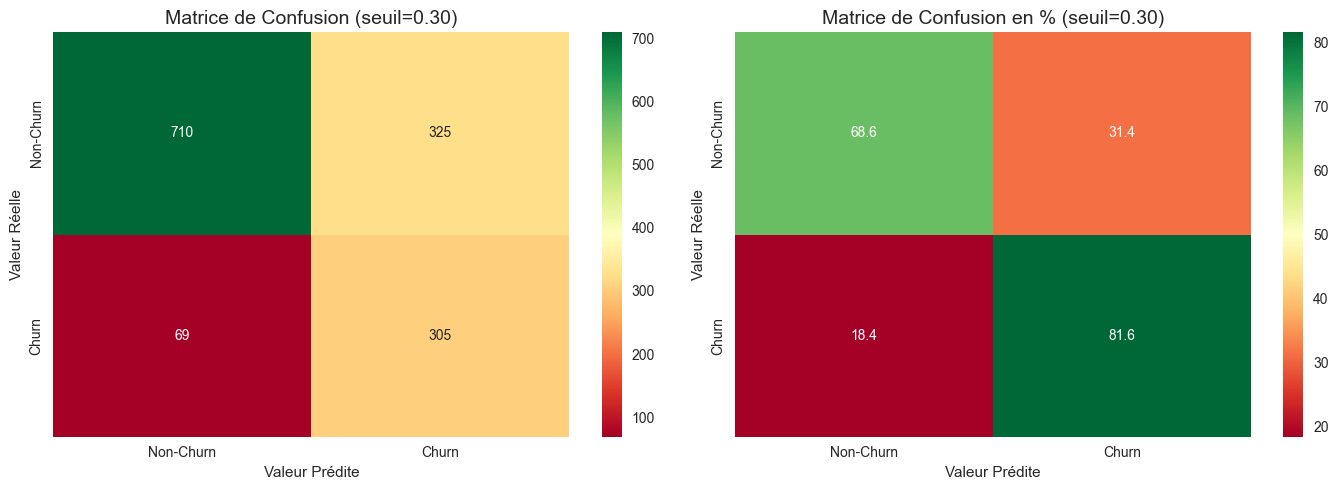


 Résumé :
   Vrais Positifs  (VP) : 305  → Churners détectés
   Vrais Négatifs  (VN) : 710  → Non-Churners corrects
    Faux Positifs  (FP) : 325  → Fausses alertes
   Faux Négatifs  (FN) : 69   → Churners manqués

 Impact financier :
  Revenus sauvés    : 305 × 200€ = 61,000€
  Coût campagnes    : 325 × 20€  = 6,500€
  Gain net          : 54,500€ ✅


In [15]:
# =============================================================
# MATRICE DE CONFUSION FINALE
# =============================================================

cm = confusion_matrix(y_test, y_pred_final)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Matrice en chiffres
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='RdYlGn',
            xticklabels=['Non-Churn', 'Churn'],
            yticklabels=['Non-Churn', 'Churn'],
            ax=axes[0])
axes[0].set_title('Matrice de Confusion (seuil=0.30)', fontsize=14)
axes[0].set_ylabel('Valeur Réelle')
axes[0].set_xlabel('Valeur Prédite')

# Graphique 2 : Matrice en pourcentage
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_pct,
            annot=True,
            fmt='.1f',
            cmap='RdYlGn',
            xticklabels=['Non-Churn', 'Churn'],
            yticklabels=['Non-Churn', 'Churn'],
            ax=axes[1])
axes[1].set_title('Matrice de Confusion en % (seuil=0.30)', fontsize=14)
axes[1].set_ylabel('Valeur Réelle')
axes[1].set_xlabel('Valeur Prédite')

plt.tight_layout()
plt.show()

# Résumé
vn, fp, fn, vp = cm.ravel()
print(f"\n Résumé :")
print(f"   Vrais Positifs  (VP) : {vp}  → Churners détectés")
print(f"   Vrais Négatifs  (VN) : {vn}  → Non-Churners corrects")
print(f"    Faux Positifs  (FP) : {fp}  → Fausses alertes")
print(f"   Faux Négatifs  (FN) : {fn}   → Churners manqués")
print(f"\n Impact financier :")
print(f"  Revenus sauvés    : {vp} × 200€ = {vp*200:,}€")
print(f"  Coût campagnes    : {fp} × 20€  = {fp*20:,}€")
print(f"  Gain net          : {vp*200 - fp*20:,}€ ✅")

##  14. Sauvegarde du Modèle

On sauvegarde le modèle final et le seuil optimal
pour les réutiliser dans l'API FastAPI.

In [16]:
# =============================================================
# SAUVEGARDE DU MODÈLE FINAL
# =============================================================

import pickle
import json

# 1. Sauvegarder le modèle XGBoost
model_path = '../models/xgb_churn_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(xgb_final, f)

# 2. Sauvegarder le seuil optimal et les métadonnées
metadata = {
    'seuil_optimal': 0.30,
    'features': list(X_train.columns),
    'performances': {
        'recall': round(recall_final, 3),
        'precision': round(precision_final, 3),
        'f1_score': round(f1_final, 3),
        'auc': round(auc_final, 3)
    }
}

metadata_path = '../models/model_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4)

# Vérification
print(" Modèle sauvegardé avec succès !")
print(f" Modèle    : {model_path}")
print(f" Métadonnées : {metadata_path}")
print(f"\n Performances du modèle sauvegardé :")
print(f"  Recall    : {recall_final:.1%}")
print(f"  Precision : {precision_final:.1%}")
print(f"  F1-Score  : {f1_final:.3f}")
print(f"  AUC       : {auc_final:.3f}")
print(f"  Seuil     : {metadata['seuil_optimal']}")

 Modèle sauvegardé avec succès !
 Modèle    : ../models/xgb_churn_model.pkl
 Métadonnées : ../models/model_metadata.json

 Performances du modèle sauvegardé :
  Recall    : 81.6%
  Precision : 48.4%
  F1-Score  : 0.608
  AUC       : 0.825
  Seuil     : 0.3


##  15. Explicabilité du Modèle avec SHAP

SHAP (SHapley Additive exPlanations) explique pourquoi le modèle
fait chaque prédiction.

On va donc analyser :
- **Feature Importance globale** : quelles variables influencent le plus le modèle ?
- **SHAP Summary Plot** : impact positif/négatif de chaque variable
- **Explication individuelle** : pourquoi le modèle prédit X pour un client spécifique

In [17]:
# =============================================================
# SHAP - EXPLICABILITÉ DU MODÈLE
# =============================================================

import shap

# Initialiser l'explainer SHAP pour XGBoost
print(" Calcul des valeurs SHAP...")
explainer = shap.TreeExplainer(xgb_final)

# Calculer les valeurs SHAP sur les données de test
shap_values = explainer.shap_values(X_test)

print(" Valeurs SHAP calculées !")
print(f" Shape des valeurs SHAP : {shap_values.shape}")

 Calcul des valeurs SHAP...
 Valeurs SHAP calculées !
 Shape des valeurs SHAP : (1409, 32)


Les valeurs SHAP sont calculées pour les 1409 clients de test sur 32 variables.

###  Feature Importance Globale

Le Summary Plot montre :
- **L'axe Y** : les variables classées par importance
- **L'axe X** : l'impact sur la prédiction (positif = pousse vers churn)
- **La couleur** : valeur de la variable (rouge = élevée, bleu = faible)

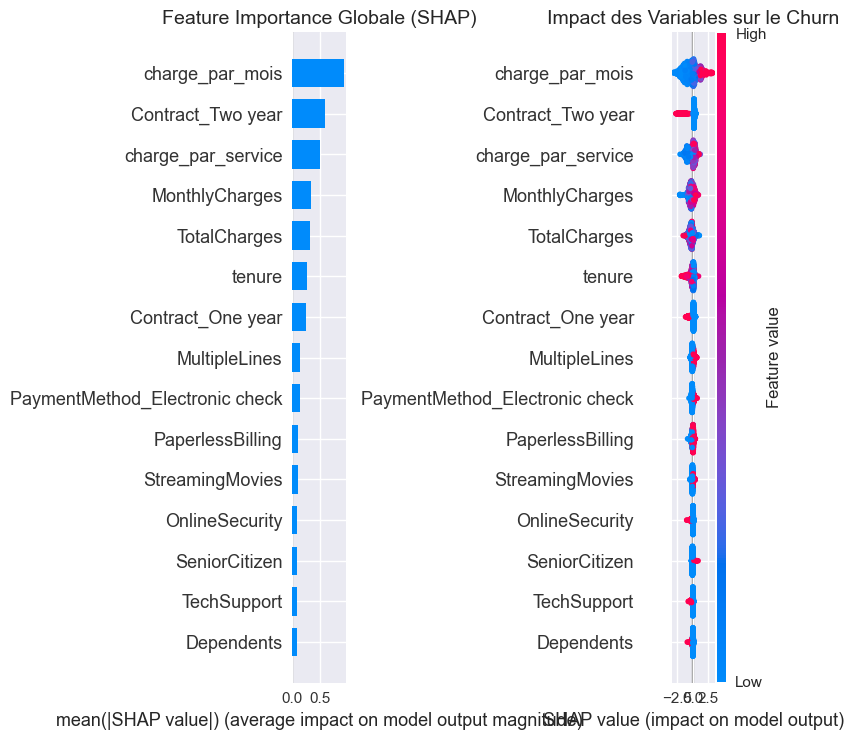

 Graphiques SHAP sauvegardés !


In [18]:
# =============================================================
# SHAP SUMMARY PLOT
# =============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Graphique 1 : Feature Importance (bar plot)
plt.subplot(1, 2, 1)
shap.summary_plot(
    shap_values, 
    X_test,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("Feature Importance Globale (SHAP)", fontsize=14)

# Graphique 2 : Summary Plot (beeswarm)
plt.subplot(1, 2, 2)
shap.summary_plot(
    shap_values,
    X_test,
    max_display=15,
    show=False
)
plt.title("Impact des Variables sur le Churn", fontsize=14)

plt.tight_layout()
plt.savefig('../models/shap_summary.png', bbox_inches='tight', dpi=150)
plt.show()

print(" Graphiques SHAP sauvegardés !")

Le premier graphique montre les variables les plus importantes (gauche) :

- charge_par_mois (une variable que j'ai crée)
- Contract_Two year (contrat 2 ans protège du churn)
- charge_par_service (autre variable crée) 
- MonthlyCharges (charges mensuelles)
- TotalCharges (charges totales)
- tenure (ancienneté)

Mon Feature Engineering a vraiment aidé car les 2 premières et 3ème variables les plus importantes sont des variables que j'ai crée moi-mêmes.

Le Graphique de droite (beeswarm) :

- charge_par_mois élevé (rouge) donc pousse vers le churn
- Contract_Two year = 1 (rouge) donc réduit le churn
- enure élevé (rouge) donc réduit le churn

###  Explication Individuelle

On explique pourquoi le modèle prédit un churn
pour un client spécifique à risque élevé.

 Client à risque élevé (index 1259) :
   Probabilité de churn : 99.7%
   Vrai label : Churn 

 Top 10 variables qui influencent la prédiction :
          Variable  SHAP Value Feature Value
   charge_par_mois    3.231231        38.575
charge_par_service    0.650081     25.716667
    MonthlyCharges    0.508028         77.15
 Contract_Two year    0.252202         False
      TotalCharges    0.174252         77.15
 Contract_One year    0.168275         False
            tenure    0.162752             1
  PaperlessBilling    0.152352             1
     MultipleLines    0.133794             1
    OnlineSecurity    0.122659             0


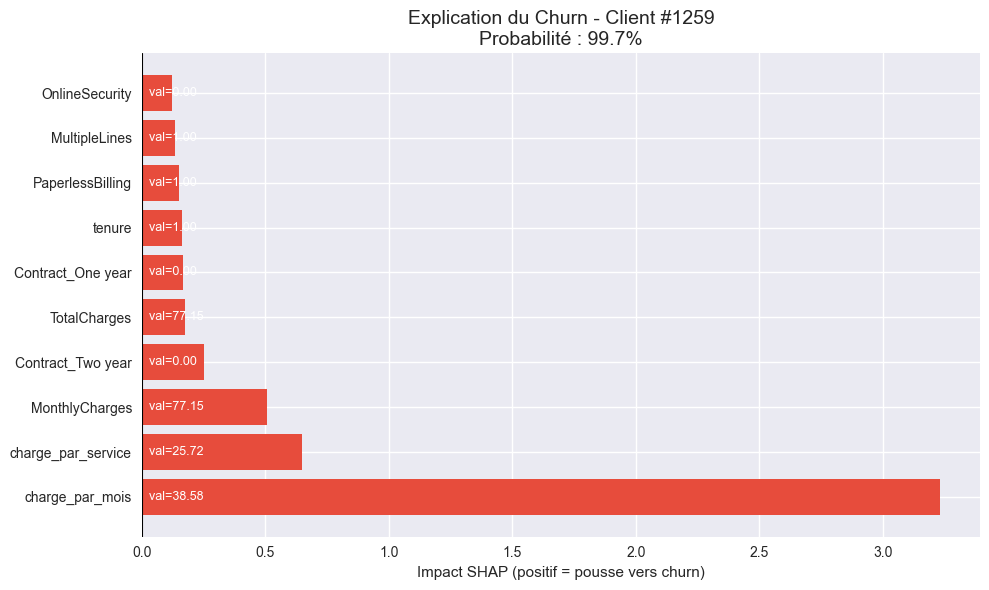

In [19]:
# =============================================================
# EXPLICATION INDIVIDUELLE - CLIENT À RISQUE ÉLEVÉ
# =============================================================

# Trouver un client à risque élevé dans le test
y_proba_test = xgb_final.predict_proba(X_test)[:, 1]
idx_high_risk = np.argmax(y_proba_test)  # Client avec la plus haute probabilité

print(f" Client à risque élevé (index {idx_high_risk}) :")
print(f"   Probabilité de churn : {y_proba_test[idx_high_risk]:.1%}")
print(f"   Vrai label : {'Churn ' if y_test.iloc[idx_high_risk] == 1 else 'Non-Churn ❌'}")

# Valeurs SHAP pour ce client
shap_client = shap_values[idx_high_risk]

# Top 10 variables qui influencent la prédiction
feature_names = X_test.columns.tolist()
shap_df = pd.DataFrame({
    'Variable': feature_names,
    'SHAP Value': shap_client,
    'Feature Value': X_test.iloc[idx_high_risk].values
}).sort_values('SHAP Value', key=abs, ascending=False).head(10)

print(f"\n Top 10 variables qui influencent la prédiction :")
print(shap_df.to_string(index=False))

# Visualisation
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in shap_df['SHAP Value']]
bars = ax.barh(shap_df['Variable'], shap_df['SHAP Value'], color=colors)
ax.set_xlabel('Impact SHAP (positif = pousse vers churn)')
ax.set_title(f'Explication du Churn - Client #{idx_high_risk}\n'
             f'Probabilité : {y_proba_test[idx_high_risk]:.1%}', fontsize=14)
ax.axvline(x=0, color='black', linewidth=0.8)

# Ajouter les valeurs des features
for i, (_, row) in enumerate(shap_df.iterrows()):
    ax.text(0.002, i, f"  val={row['Feature Value']:.2f}",
            va='center', fontsize=9, color='white')

plt.tight_layout()
plt.savefig('../models/shap_individual.png', bbox_inches='tight', dpi=150)
plt.show()

Pourquoi ce client va partir (toutes les barres sont rouges) :

- charge_par_mois = 38.58 [Impact énorme (+3.23)] ie qu'il paye beaucoup par rapport à son ancienneté (1 mois seulement).
- charge_par_service = 25.72 donc il paye cher par rapport aux services qu'il a
- MonthlyCharges = 77.15€ (Charges élevées)
- Contract_Two year = 0 (Pas d'engagement long terme)
- Contract_One year = 0 (Pas d'engagement du tout)
- tenure = 1 (Nouveau client (1 mois ))

Ce client est le profil parfait du churner :

- Nouveau client (1 mois)
- Paye cher (77€/mois)
- Sans engagement
- Sans sécurité en ligne

Action recommandée : Contacter immédiatement et proposer un contrat annuel avec réduction.